# Cross Validation and Regularization

**Scaler CML | Applied ML (Intro)**  
**Instructor:** Chitwan Manchanda  
**Session:** CML Group B | Session 7 (follows Polynomial Regression / Bias-Variance)

Companion notes: `CML7_Notes.md`

---


# 1. Agenda

Live-class spine (in order):

1. Why regularization (overfitting from high-degree / many features)
2. L2 (Ridge) loss, $\lambda$, sweet spot
3. L1 (Lasso), sparsity, when Ridge vs Lasso
4. ElasticNet
5. Code: diabetes + polynomial features, alpha effect
6. Parameters vs hyperparameters
7. Holdout trap: do not tune on the test set
8. Train / validation / test + cross-validation
9. K-fold CV (small data)
10. Choosing `alpha` with CV (`RidgeCV` / `LassoCV`)
11. Pitfalls: scaling, leakage, peeking at test

Skip classroom announcements; stay on concepts + demos + quizzes.


# 2. Motivation: too many high-degree features

## Talking track

From Session 6: high polynomial degree can hug every training point (overfit).

Cause story to plant:

- Too many high-degree features give the model freedom to wiggle.
- Influence of a feature is carried by its weight $w_j$.
- Idea: shrink (or zero) weights that fuel the wiggles.

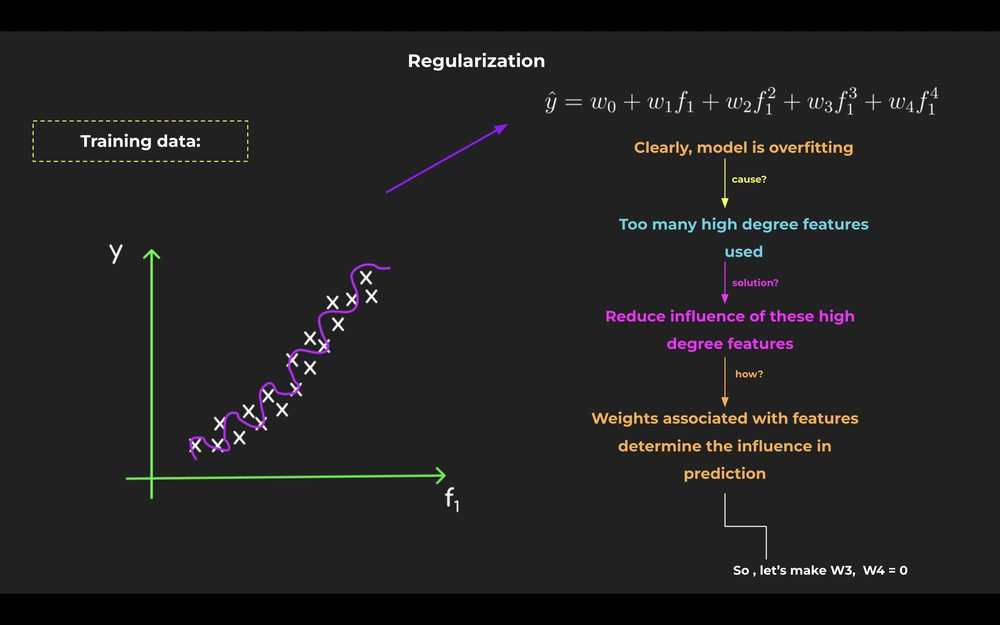

**Plant the question:** How do we push $w_3, w_4 \approx 0$ while still fitting the useful $w_1, w_2$?


# 3. New loss: fit + penalty (L2 / Ridge)

## Talking track

Ordinary least squares only cares about MSE. Add a **penalty on weight size**:

$$
\mathrm{loss}(w) = \underbrace{\frac{1}{n}\sum_{i=1}^{n}\big(y^{(i)} - \hat{y}^{(i)}\big)^2}_{\text{MSE}} + \underbrace{\lambda \sum_{j=1}^{d} w_j^{2}}_{\text{L2 / Ridge}}
$$

with $\hat{y}^{(i)} = w^{\top} x^{(i)} + w_0$.

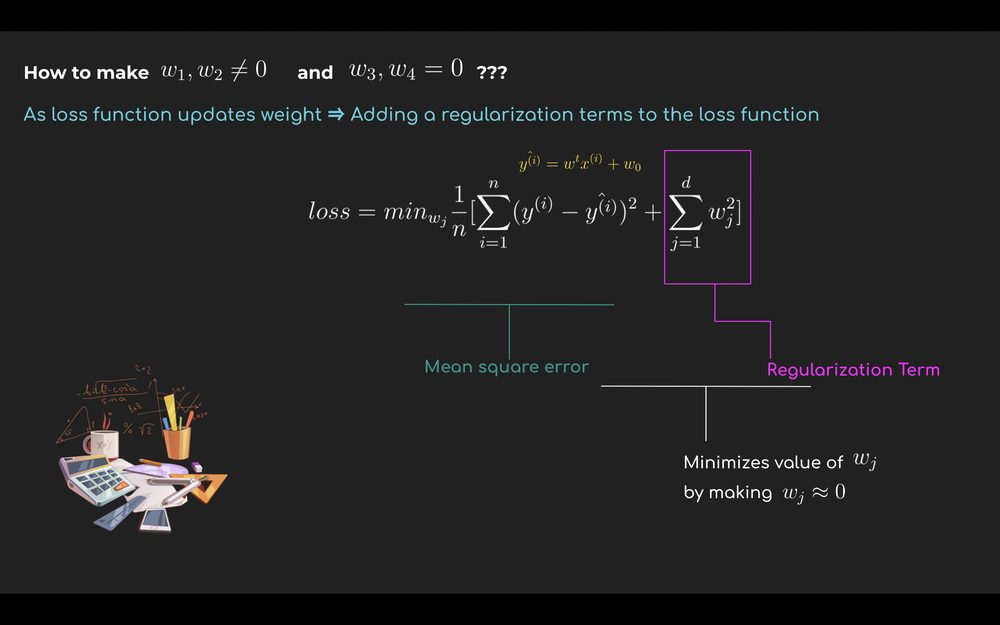

- The MSE term wants good fit.
- The $\sum w_j^2$ term wants small weights.
- Gradient descent (or closed form for Ridge) balances both.

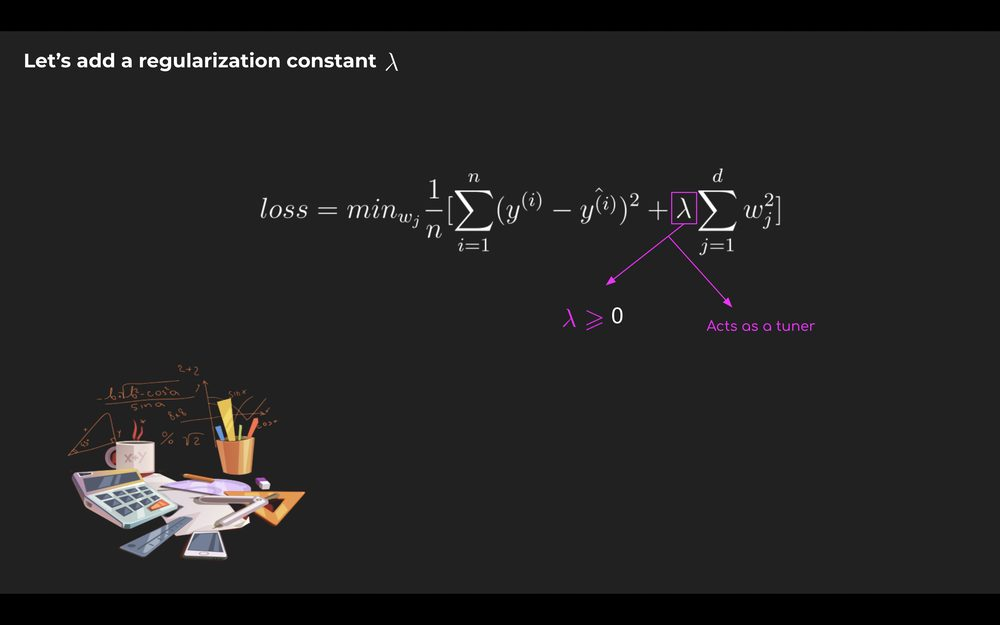

**Note:** In sklearn, the same knob is named `alpha` (same role as $\lambda$).


# 4. The sweet spot for $\lambda$

## Talking track

$\lambda$ (sklearn `alpha`) is the **regularization strength**:

| $\lambda$ | Effect | Risk |
|---|---|---|
| Near 0 | Almost plain OLS | Overfit |
| Moderate | Shrink weights, keep signal | Target zone |
| Huge | Weights crushed toward 0 | Underfit |

Say out loud: enough freedom for MSE to fit, enough pressure from the penalty so we do not memorize noise.

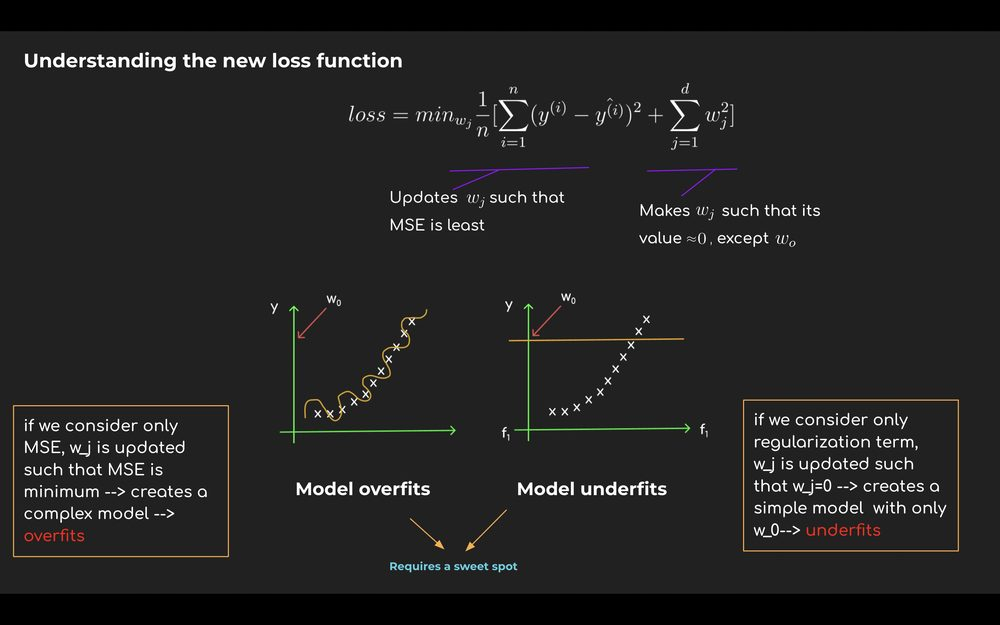

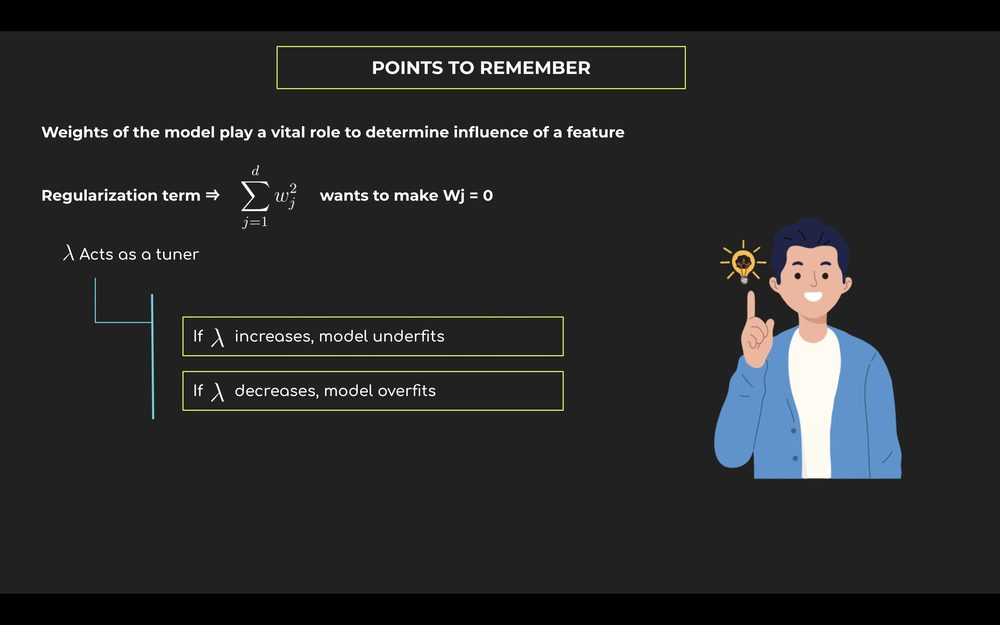

**Class rule:** $\lambda$ is a **hyperparameter**. You do not learn it with the same GD step as $w$. You choose it with validation / CV.


# Quiz 1

**What is the role of $\lambda$ in preventing overfitting?**

- It increases overfitting
- It decreases underfitting
- It helps find the optimal trade-off
- It has no impact on overfitting


# 5. L1 Regularization (Lasso)

## Talking track

Replace the squared penalty with absolute values:

$$
\mathrm{loss}(w) = \mathrm{MSE} + \lambda \sum_{j=1}^{d} |w_j|
$$

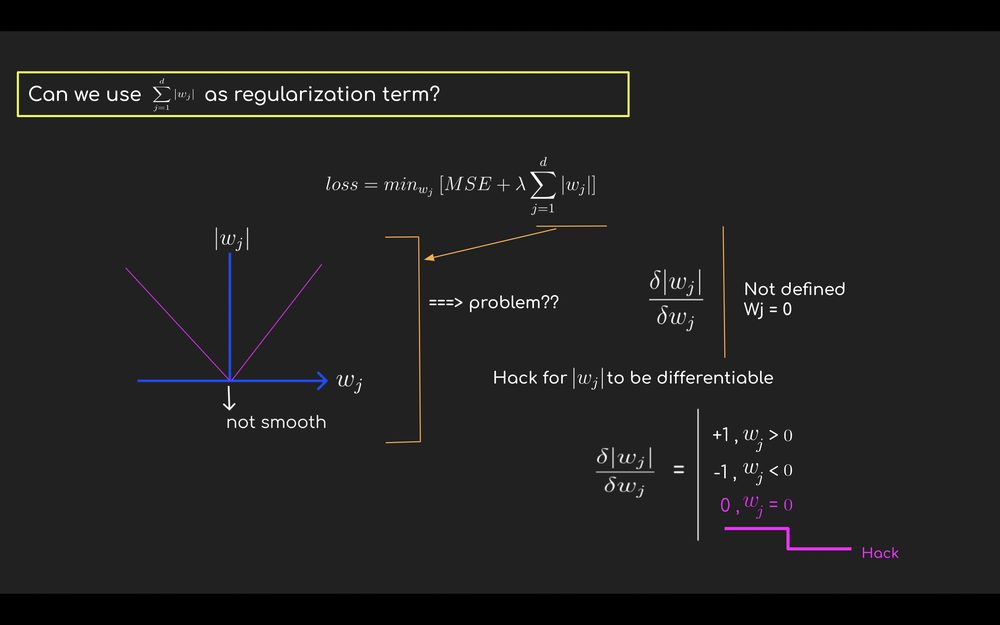

$|w_j|$ is not differentiable at 0. In practice we use a **subgradient** "hack":

$$
\frac{\partial |w_j|}{\partial w_j} \in \{+1, 0, -1\}
$$

(depending on the sign of $w_j$, and 0 at the kink).

## Why L1 creates sparse $w$ (and L2 does not)

Weight update:

$$
w_j \leftarrow w_j - \eta \frac{\partial L}{\partial w_j}
$$

- L1 subgradient is **independent of how small $w_j$ is** (constant push). Weights can hit **exact 0**.
- L2 gradient is $2w_j$ (**depends on $w_j$**). Near zero the push shrinks, so weights stay **small but usually nonzero**.

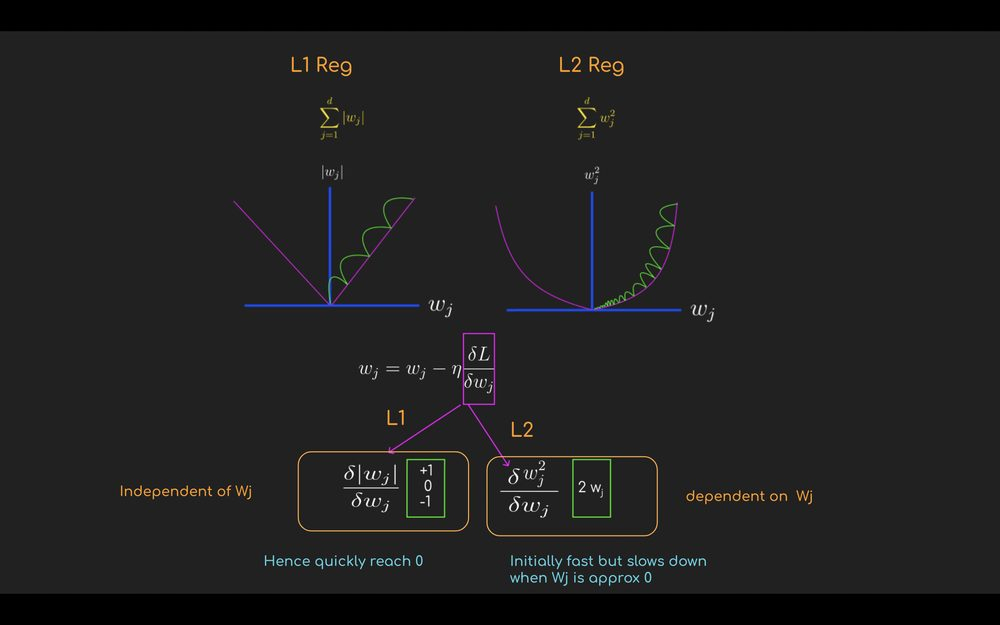


# 6. When to use Ridge vs Lasso vs ElasticNet

## Talking track

| Method | Penalty | Typical use |
|---|---|---|
| **Ridge (L2)** | $\sum w_j^2$ | Correlated features; keep all features, shrink them |
| **Lasso (L1)** | $\sum |w_j|$ | Want automatic feature selection / sparse $w$ |
| **ElasticNet** | mix of L1 + L2 | Unsure; groups of correlated features; need some sparsity + stability |

ElasticNet loss (intuition):

$$
\mathrm{MSE} + \lambda_1 \sum |w_j| + \lambda_2 \sum w_j^2
$$

(sklearn: `ElasticNet(alpha=..., l1_ratio=...)` mixes the two).

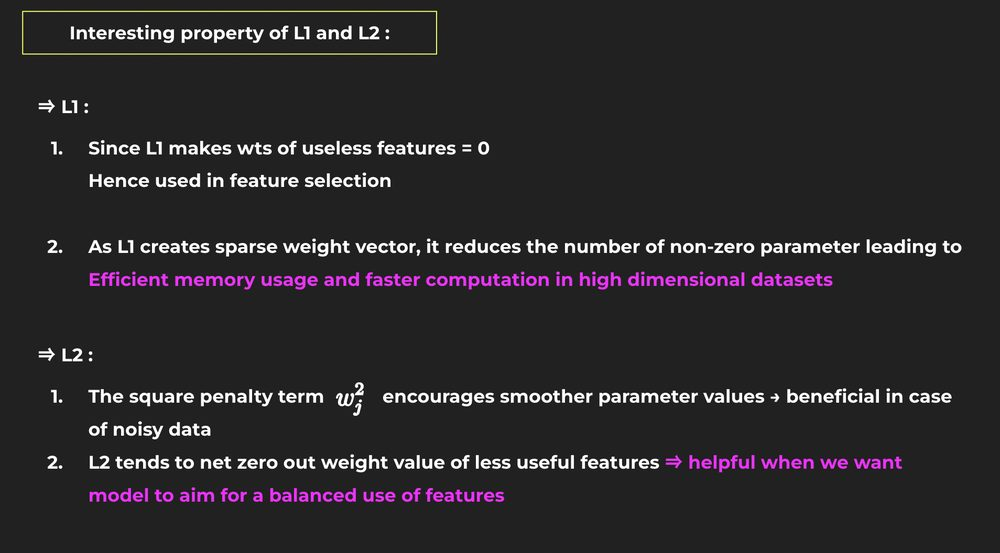

**Scaling reminder (say early):** Regularization penalizes weight *magnitude*. If one feature is in meters and another in millimeters, the penalty is unfair. **Always scale features before Ridge / Lasso / ElasticNet** (fit scaler on train only).


# 7. Code demo: diabetes + high-degree poly (overfit), then regularize

## Demo beats

1. Load sklearn **diabetes** (442 samples, 10 numeric features).
2. Train/test split, `PolynomialFeatures(degree=5)  # script used 8; 5 keeps runtime sane`, `StandardScaler`.
3. Fit plain `LinearRegression` → train near-perfect, test collapses (overfit).
4. Try `Lasso` / `Ridge` with tiny `alpha`, huge `alpha`, then a reasonable `alpha`.
5. Narrate: regularization can rescue a too-flexible feature map when $\alpha$ is chosen well.

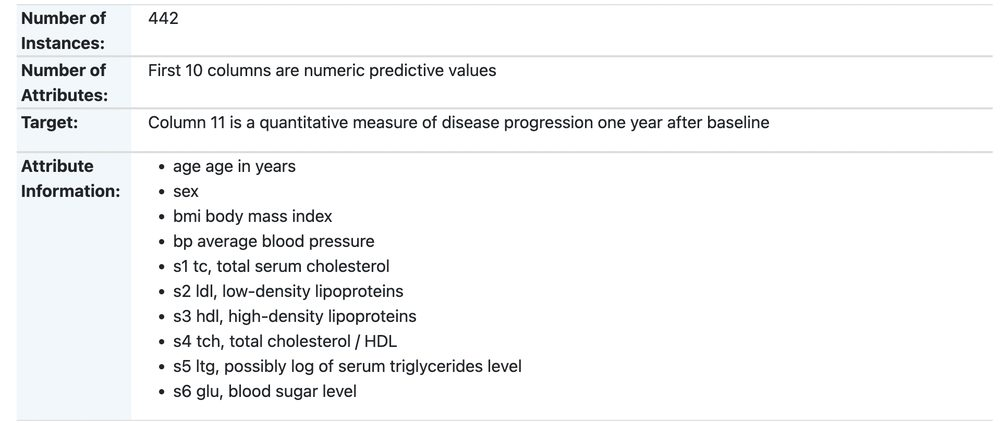

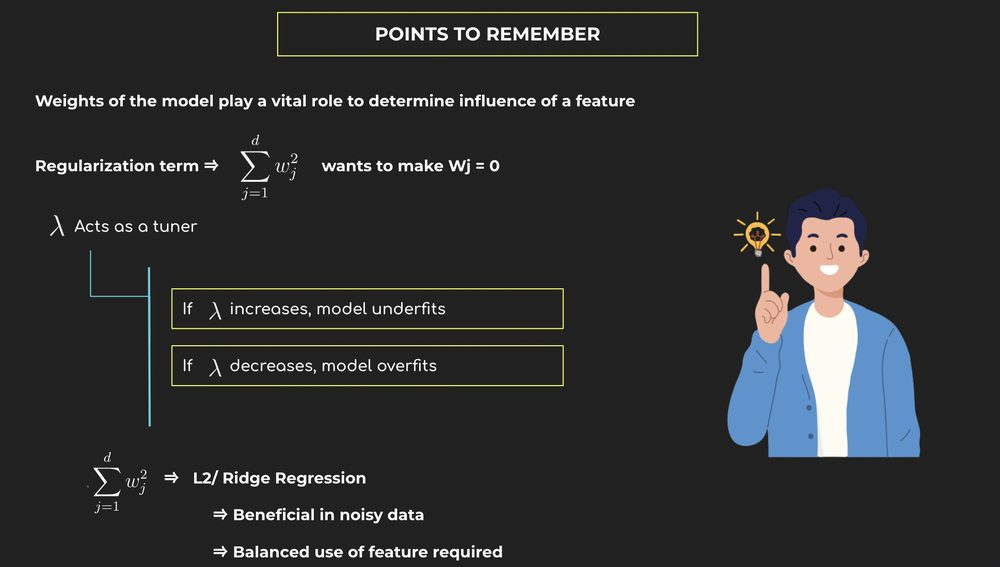


In [1]:
%matplotlib inline
import numpy as np
import matplotlib.pyplot as plt
from sklearn import datasets
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import PolynomialFeatures, StandardScaler
from sklearn.linear_model import LinearRegression, Ridge, Lasso, ElasticNet
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.pipeline import make_pipeline

np.random.seed(42)

data = datasets.load_diabetes()
X, y = data["data"] , data["target"] # target
print("X shape:", X.shape, "| feature names:", list(data["feature_names"]))

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Script used degree=8 (huge feature blast). We use degree=5 here so the
# live notebook stays responsive, while still clearly overfitting.
degree = 5
poly = PolynomialFeatures(degree=degree, include_bias=False)
scaler = StandardScaler()

X_train_poly = poly.fit_transform(X_train)
X_test_poly = poly.transform(X_test)
X_train_s = scaler.fit_transform(X_train_poly)
X_test_s = scaler.transform(X_test_poly)

print("Poly feature width:", X_train_s.shape[1])

ols = LinearRegression()
ols.fit(X_train_s, y_train)
print("OLS train R2:", round(ols.score(X_train_s, y_train), 4)) # R2 sqaure score
print("OLS test  R2:", round(ols.score(X_test_s, y_test), 4))
print("OLS test  MSE:", round(mean_squared_error(y_test, ols.predict(X_test_s)), 2))


X shape: (442, 10) | feature names: ['age', 'sex', 'bmi', 'bp', 's1', 's2', 's3', 's4', 's5', 's6']
Poly feature width: 3002
OLS train R2: 1.0
OLS test  R2: -11.8683
OLS test  MSE: 68178.08


In [12]:
# data

**Observe:** High-degree poly features on ~350 training rows creates a huge feature space. Train $R^2$ can look perfect while test $R^2$ is terrible. That is classic overfitting.


In [2]:
def report(name, model):
    model.fit(X_train_s, y_train)
    tr = model.score(X_train_s, y_train)
    te = model.score(X_test_s, y_test)
    mse = mean_squared_error(y_test, model.predict(X_test_s))
    nnz = np.sum(np.abs(getattr(model, "coef_", np.array([]))) > 1e-8)
    print(f"{name:28s} train R2={tr:7.3f}  test R2={te:7.3f}  test MSE={mse:9.1f}  nonzero={nnz}")

# Tiny alpha: almost no regularization
report("Lasso alpha=0.01", Lasso(alpha=0.01, max_iter=8000, tol=1e-3))
report("Ridge alpha=0.01", Ridge(alpha=0.01))

# Huge alpha: underfit / near-constant
report("Lasso alpha=1e6", Lasso(alpha=1e6, max_iter=5000))
report("Ridge alpha=1e6", Ridge(alpha=1e6))

# More reasonable alphas (still hand-picked; CV comes later)
report("Lasso alpha=1.0", Lasso(alpha=1.0, max_iter=8000, tol=1e-3))
report("Ridge alpha=100", Ridge(alpha=1.0))
report("ElasticNet a=1, l1=0.5", ElasticNet(alpha=1.0, l1_ratio=0.5, max_iter=8000, tol=1e-3))


/usr/local/lib/python3.13/dist-packages/sklearn/linear_model/_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 1.044e+04, tolerance: 2.145e+03
  model = cd_fast.enet_coordinate_descent(


Lasso alpha=0.01             train R2=  0.997  test R2= -6.996  test MSE=  42363.8  nonzero=647
Ridge alpha=0.01             train R2=  1.000  test R2=-11.655  test MSE=  67050.6  nonzero=3002
Lasso alpha=1e6              train R2=  0.000  test R2= -0.012  test MSE=   5361.5  nonzero=0
Ridge alpha=1e6              train R2=  0.042  test R2=  0.031  test MSE=   5133.8  nonzero=3002
Lasso alpha=1.0              train R2=  0.721  test R2=  0.375  test MSE=   3310.9  nonzero=129
Ridge alpha=100              train R2=  0.819  test R2= -0.004  test MSE=   5317.9  nonzero=3002
ElasticNet a=1, l1=0.5       train R2=  0.704  test R2=  0.430  test MSE=   3019.3  nonzero=825


**Observe:**

- Tiny `alpha`: still overfits (bad test).
- Huge `alpha`: both methods underfit (test $R^2$ near 0 or negative).
- A mid-range `alpha` often improves test MSE / $R^2$.
- Lasso's `nonzero` count drops: sparsity in action.


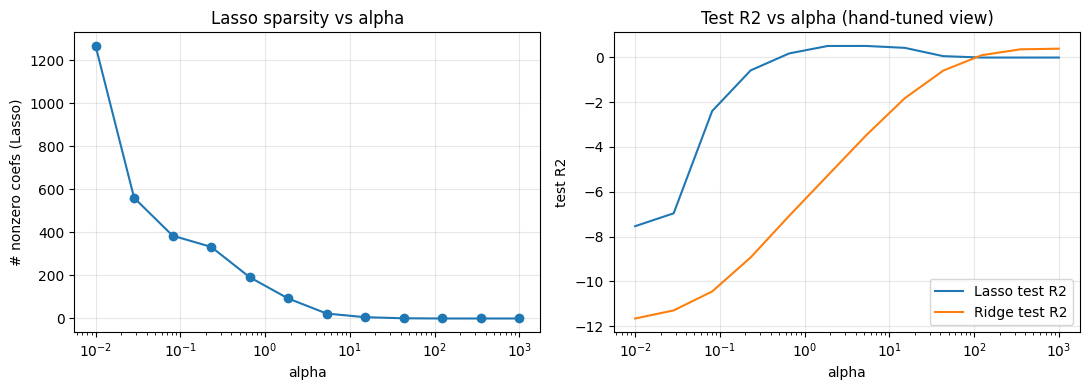

In [3]:
# Coefficient paths vs alpha (intuition plot; fewer alphas for class runtime)
alphas = np.logspace(-2, 3, 12)
lasso_nnz, lasso_test, ridge_test = [], [], []

for a in alphas:
    las = Lasso(alpha=a, max_iter=6000, tol=1e-2).fit(X_train_s, y_train)
    rid = Ridge(alpha=a).fit(X_train_s, y_train)
    lasso_nnz.append(np.sum(np.abs(las.coef_) > 1e-8))
    lasso_test.append(las.score(X_test_s, y_test))
    ridge_test.append(rid.score(X_test_s, y_test))

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
axes[0].plot(alphas, lasso_nnz, marker="o")
axes[0].set_xscale("log")
axes[0].set_xlabel("alpha")
axes[0].set_ylabel("# nonzero coefs (Lasso)")
axes[0].set_title("Lasso sparsity vs alpha")
axes[0].grid(True, alpha=0.3)

axes[1].plot(alphas, lasso_test, label="Lasso test R2")
axes[1].plot(alphas, ridge_test, label="Ridge test R2")
axes[1].set_xscale("log")
axes[1].set_xlabel("alpha")
axes[1].set_ylabel("test R2")
axes[1].set_title("Test R2 vs alpha (hand-tuned view)")
axes[1].legend()
axes[1].grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


# Quiz 2

**In which regularization technique are two regularization constants (or an equivalent mix) used?**

- L1 regularization
- L2 regularization
- Elastic Net regularization
- All of the above


# 8. Parameters vs hyperparameters

## Talking track (baker analogy)

Ingredients stay fixed; you experiment with oven temperature and bake time. That experiment is **hyperparameter tuning**.

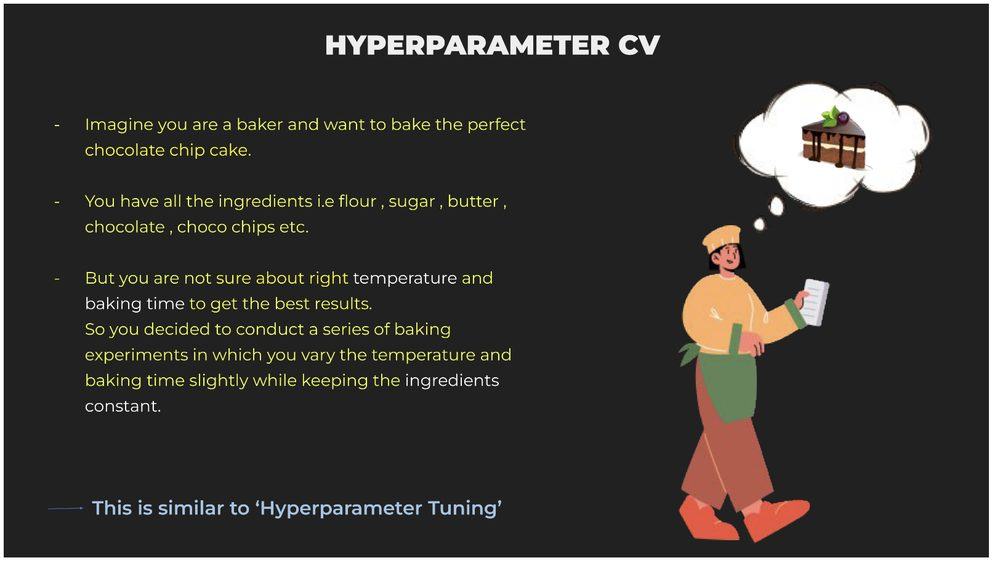

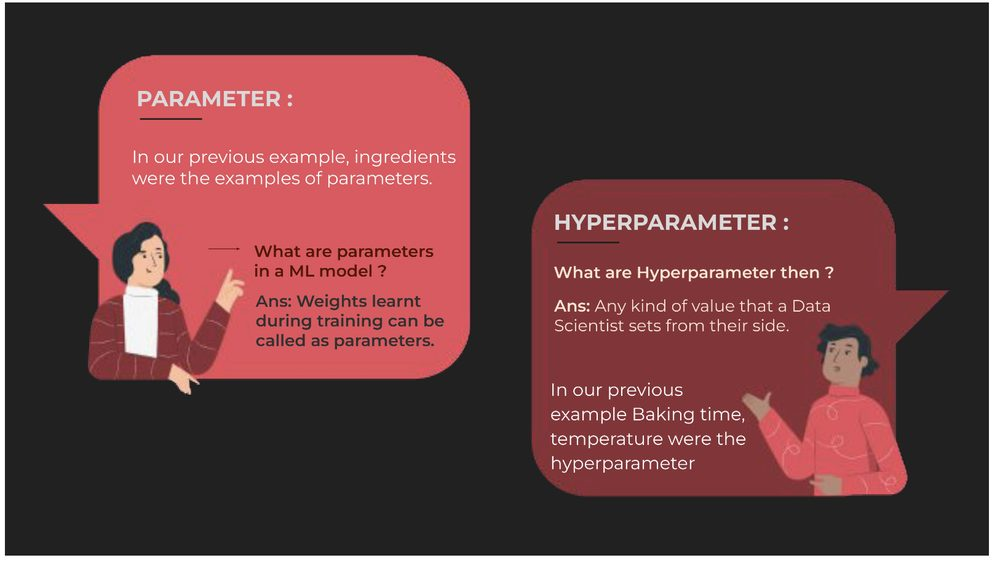

- **Parameters:** weights $w$ learned from data during training.
- **Hyperparameters:** values **you** set (degree, $\lambda$ / `alpha`, `l1_ratio`, learning rate, ...).

**How to choose them?** Not by staring at training loss alone. Use a held-out **validation** protocol (next sections).

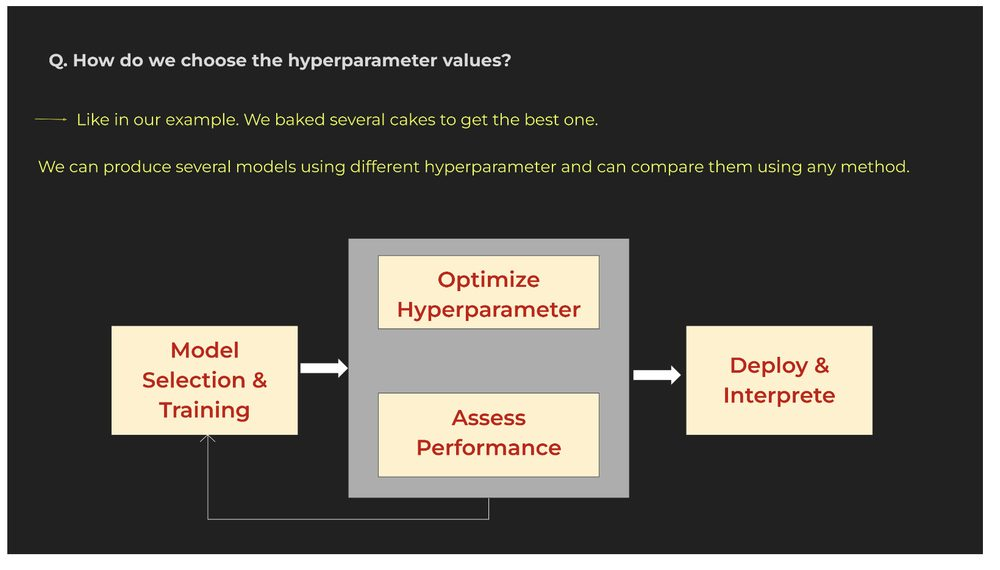


# Quiz 3

**What would a lambda / regularization rate value of 0 signify?**

- Complex and overfitting
- Complex and underfitting
- Simple and overfitting


# Quiz 4

**What would be the optimal value of lambda?**  
Note: adj. $R^2$ score is on test data (in the original slide). We will soon argue that tuning should use **validation**, not the final test set.

- Model M1, lambda=1, adj. R2 score=0.4
- Model M2, lambda=10, adj. R2 score=0.8
- Model M3, lambda=100, adj. R2 score=0.2


# 9. Hyperparameter tuning curve ($\lambda$ vs score)

## Talking track

On a synthetic curved target (same family as Session 6), fix a **high** polynomial degree and sweep Ridge `alpha`.

Expect: train score falls as $\lambda$ grows; validation / test score often peaks at a mid $\lambda$.

We will first show the **dangerous pattern** (picking $\lambda$ with the test set), then fix it with a validation split.

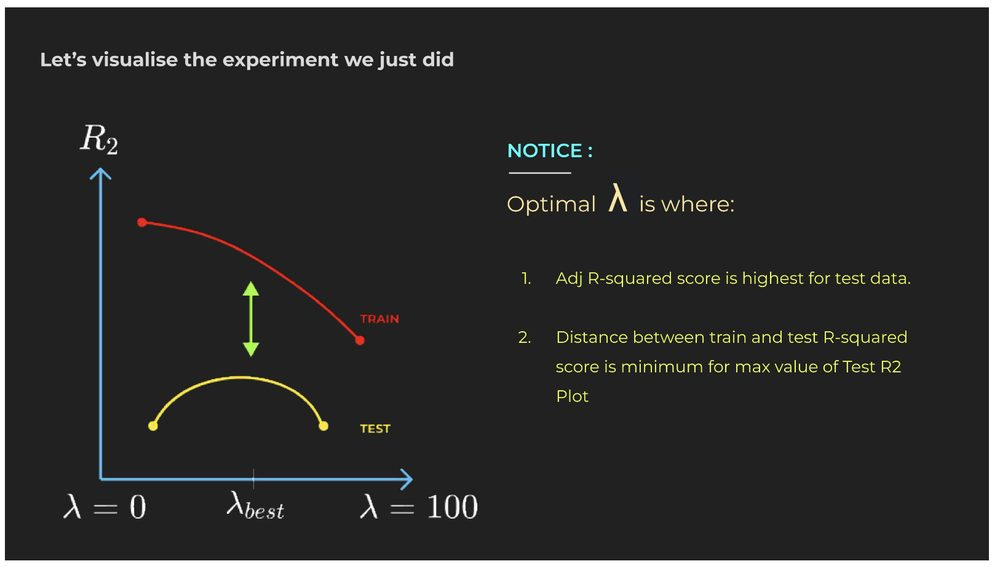


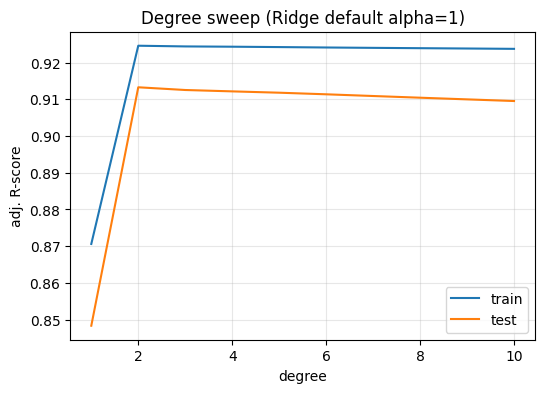

In [4]:
# Synthetic curve (Session 6 style), larger n for stable plots
np.random.seed(2)
X = np.random.rand(1000, 1)
y = (
    0.7 * (X**5)
    - 2.1 * (X**4)
    + 2.3 * (X**3)
    + 0.2 * (X**2)
    + 0.3 * X
    + 0.4 * np.random.rand(1000, 1)
)

def adj_r2(X_mat, y_true, r2):
    n = len(y_true)
    p = X_mat.shape[1]
    denom = n - p - 1
    if denom <= 0:
        return np.nan  # undefined when features >= n-1 (Session 6 reminder)
    return 1 - (1 - r2) * (n - 1) / denom

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=1
)

# Degree sweep with default Ridge (alpha=1.0)
max_degree = 11
train_scores, test_scores = [], []
for degree in range(1, max_degree):
    pipe = make_pipeline(PolynomialFeatures(degree), StandardScaler(), Ridge())
    pipe.fit(X_train, y_train)
    # adj R2 uses transformed width via named step access
    Xt = pipe.named_steps["polynomialfeatures"].transform(X_train)
    Xte = pipe.named_steps["polynomialfeatures"].transform(X_test)
    train_scores.append(adj_r2(Xt, y_train, pipe.score(X_train, y_train)))
    test_scores.append(adj_r2(Xte, y_test, pipe.score(X_test, y_test)))

plt.figure(figsize=(6, 4))
plt.plot(range(1, max_degree), train_scores, label="train")
plt.plot(range(1, max_degree), test_scores, label="test")
plt.xlabel("degree")
plt.ylabel("adj. R-score")
plt.legend(loc="lower right")
plt.grid(True, alpha=0.3)
plt.title("Degree sweep (Ridge default alpha=1)")
plt.show()


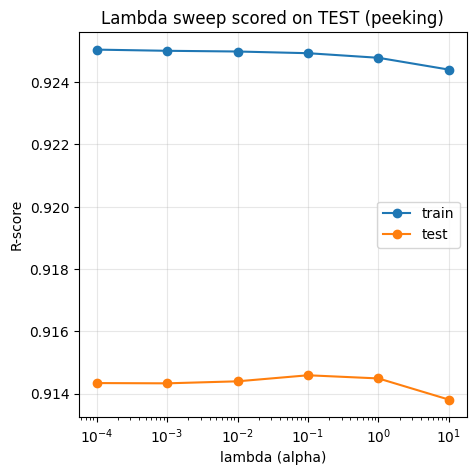

Best lambda by TEST peek: 0.1


In [5]:
# Fix degree=8, sweep lambda (alpha). NOTE: using TEST here on purpose (anti-pattern)
rate_list = [0.0001, 0.001, 0.01, 0.1, 1, 10]
train_scores, test_scores = [], []
for rate in rate_list:
    pipe = make_pipeline(
        PolynomialFeatures(8), StandardScaler(), Ridge(alpha=rate)
    )
    pipe.fit(X_train, y_train)
    train_scores.append(pipe.score(X_train, y_train))
    test_scores.append(pipe.score(X_test, y_test))

plt.figure(figsize=(5, 5))
plt.plot(rate_list, train_scores, marker="o", label="train")
plt.plot(rate_list, test_scores, marker="o", label="test")
plt.xlabel("lambda (alpha)")
plt.ylabel("R-score")
plt.xscale("log")
plt.legend()
plt.grid(True, alpha=0.3)
plt.title("Lambda sweep scored on TEST (peeking)")
plt.show()
print("Best lambda by TEST peek:", rate_list[int(np.argmax(test_scores))])


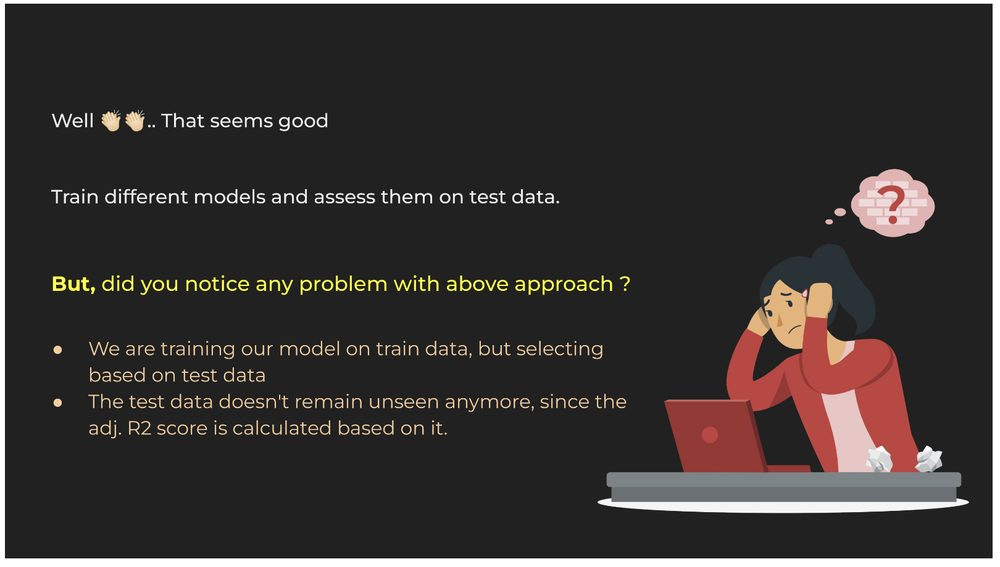

**Say out loud:** If you pick degree / $\lambda$ by repeatedly looking at the test score, the test set is no longer a clean final exam. You need a **validation** slice (or CV).


# 10. Train / validation / test (holdout CV)

## Talking track

Three roles:

1. **Train:** fit weights.
2. **Validation:** choose hyperparameters (degree, $\lambda$, ...).
3. **Test:** one-shot estimate of generalization after you freeze choices.

Common split example: 60% / 20% / 20%.

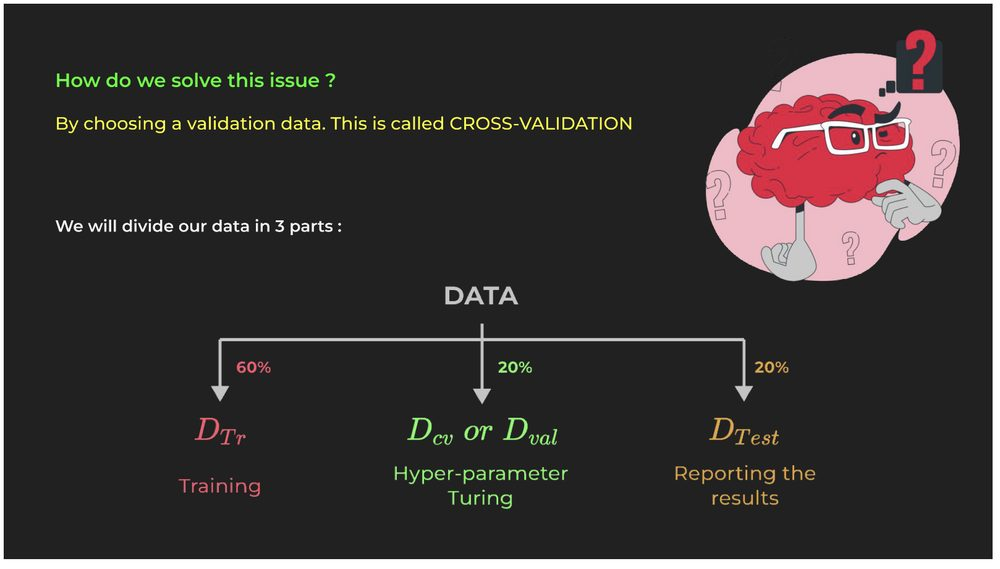

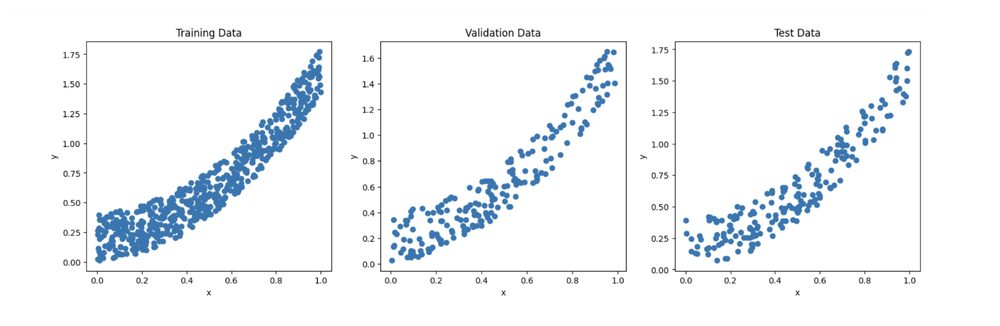


shapes: (600, 1) (200, 1) (200, 1)


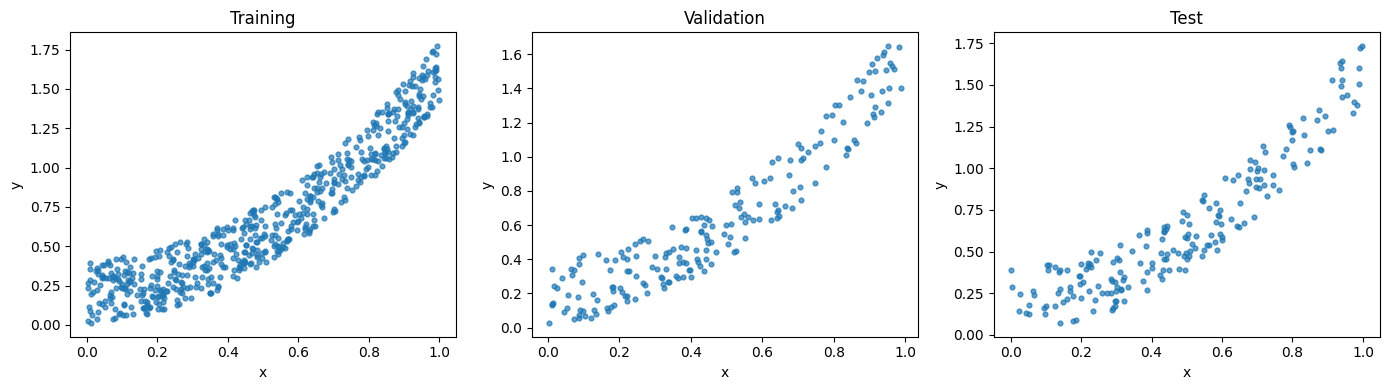

In [6]:
# Proper 60/20/20 split
X_tr_cv, X_test, y_tr_cv, y_test = train_test_split(
    X, y, test_size=0.2, random_state=1
)
X_train, X_val, y_train, y_val = train_test_split(
    X_tr_cv, y_tr_cv, test_size=0.25, random_state=1
)  # 0.25 of 80% = 20% overall
print("shapes:", X_train.shape, X_val.shape, X_test.shape)

fig, axes = plt.subplots(1, 3, figsize=(14, 4))
for ax, Xx, yy, title in zip(
    axes,
    [X_train, X_val, X_test],
    [y_train, y_val, y_test],
    ["Training", "Validation", "Test"],
):
    ax.scatter(Xx, yy, s=12, alpha=0.7)
    ax.set_title(title)
    ax.set_xlabel("x")
    ax.set_ylabel("y")
plt.tight_layout()
plt.show()


Best degree by validation: 2


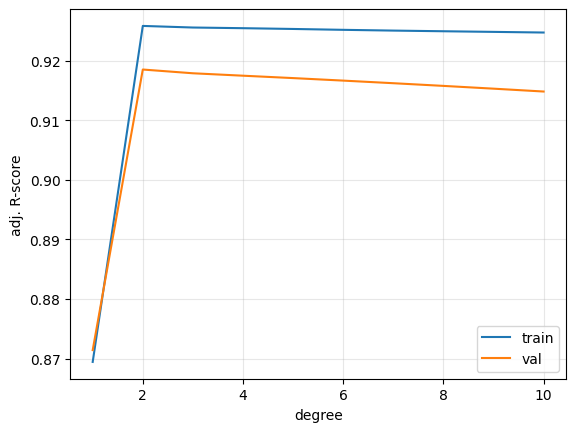

In [7]:
# Choose degree on VALIDATION (not test)
max_degree = 11
train_scores, val_scores = [], []
for degree in range(1, max_degree):
    pipe = make_pipeline(PolynomialFeatures(degree), StandardScaler(), Ridge())
    pipe.fit(X_train, y_train)
    Xt = pipe.named_steps["polynomialfeatures"].transform(X_train)
    Xv = pipe.named_steps["polynomialfeatures"].transform(X_val)
    train_scores.append(adj_r2(Xt, y_train, pipe.score(X_train, y_train)))
    val_scores.append(adj_r2(Xv, y_val, pipe.score(X_val, y_val)))

best_degree = int(np.argmax(val_scores)) + 1
print("Best degree by validation:", best_degree)

plt.figure()
plt.plot(range(1, max_degree), train_scores, label="train")
plt.plot(range(1, max_degree), val_scores, label="val")
plt.xlabel("degree")
plt.ylabel("adj. R-score")
plt.legend(loc="lower right")
plt.grid(True, alpha=0.3)
plt.show()


Best lambda by validation: 0.1


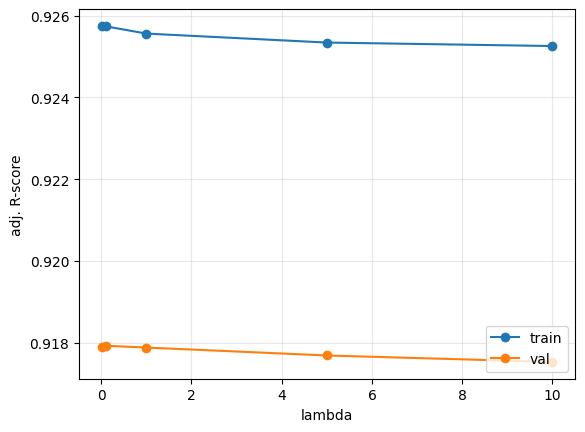

Training Score = 0.9257396439626613
Validation Score = 0.9179307708810596
Testing Score = 0.9129665778439827


In [8]:
# Choose lambda on VALIDATION with fixed degree (use 3 if it won, else best_degree)
degree_star = 3  # matches original script narrative; also print best_degree above
rate_list = [0.01, 0.1, 1, 5, 10]
train_scores, val_scores = [], []
for rate in rate_list:
    pipe = make_pipeline(
        PolynomialFeatures(degree_star), StandardScaler(), Ridge(alpha=rate)
    )
    pipe.fit(X_train, y_train)
    Xt = pipe.named_steps["polynomialfeatures"].transform(X_train)
    Xv = pipe.named_steps["polynomialfeatures"].transform(X_val)
    train_scores.append(adj_r2(Xt, y_train, pipe.score(X_train, y_train)))
    val_scores.append(adj_r2(Xv, y_val, pipe.score(X_val, y_val)))

best_rate = rate_list[int(np.argmax(val_scores))]
print("Best lambda by validation:", best_rate)

plt.figure()
plt.plot(rate_list, train_scores, marker="o", label="train")
plt.plot(rate_list, val_scores, marker="o", label="val")
plt.xlabel("lambda")
plt.ylabel("adj. R-score")
plt.legend(loc="lower right")
plt.grid(True, alpha=0.3)
plt.show()

# Freeze choices, report TEST once
final = make_pipeline(
    PolynomialFeatures(degree_star), StandardScaler(), Ridge(alpha=best_rate)
)
final.fit(X_train, y_train)
Xt = final.named_steps["polynomialfeatures"].transform(X_train)
Xv = final.named_steps["polynomialfeatures"].transform(X_val)
Xte = final.named_steps["polynomialfeatures"].transform(X_test)
print("Training Score =", adj_r2(Xt, y_train, final.score(X_train, y_train)))
print("Validation Score =", adj_r2(Xv, y_val, final.score(X_val, y_val)))
print("Testing Score =", adj_r2(Xte, y_test, final.score(X_test, y_test)))


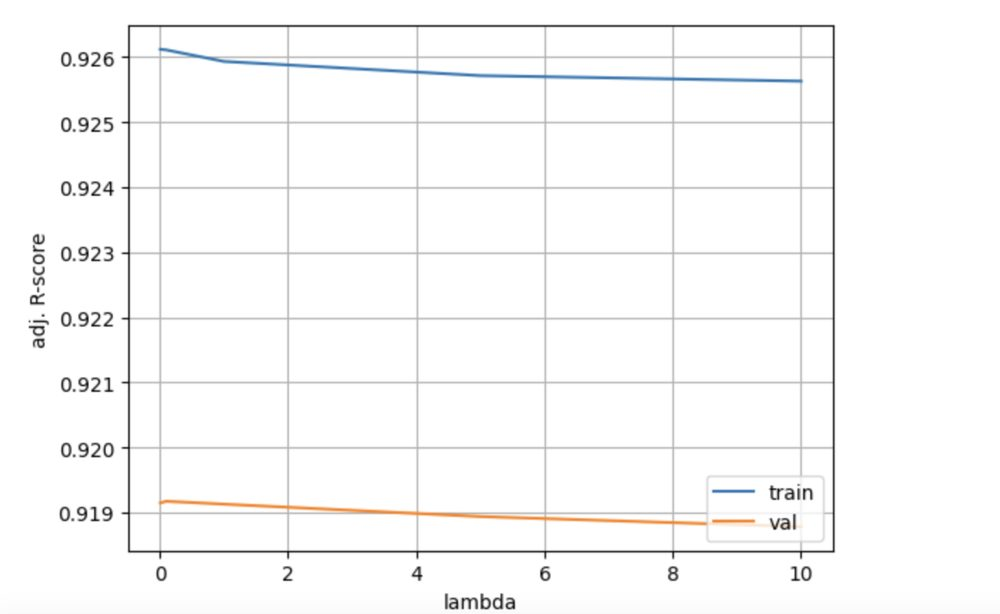

**Observe:** Test is usually a bit lower than train/val. That is fine. It is the honest number after you stopped peeking.

**Try for yourself later:** swap `Ridge` for `LinearRegression`, `Lasso`, and `ElasticNet` on the same splits.


# Quiz 5

**A company is building a predictive model for predicting customer churn. Which technique can help optimize the model's performance for selecting the best hyperparameters and evaluating its generalization ability?**

- Sampling
- Feature selection.
- Ensemble learning.
- Hyperparameter tuning using Cross-validation.


# 11. K-Fold Cross Validation

## Talking track

Single validation split wastes data and can be noisy when $n$ is small.

**K-fold idea:**

1. Split data into $K$ folds.
2. For each fold $i$: train on the other $K-1$, validate on fold $i$.
3. Average the $K$ validation scores.

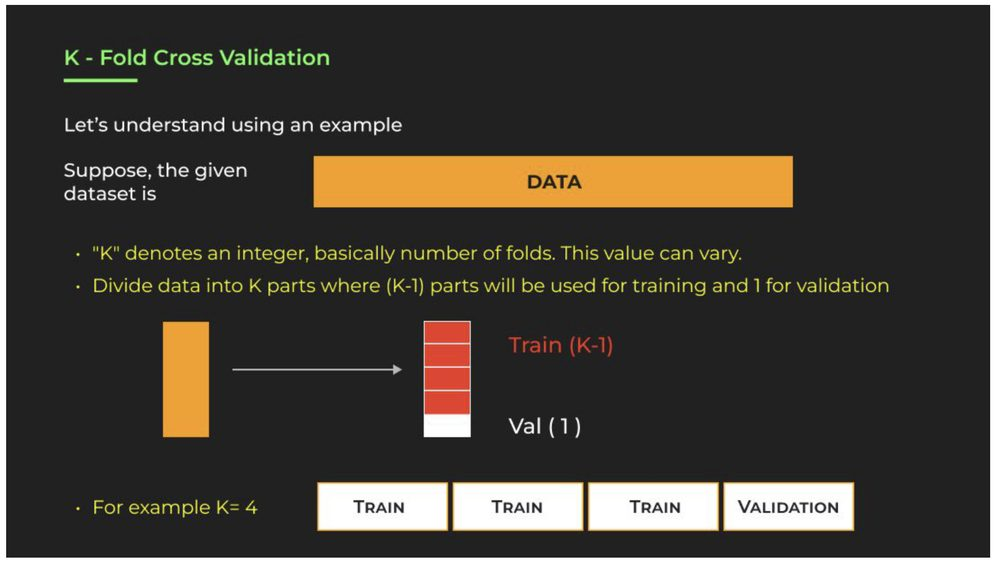

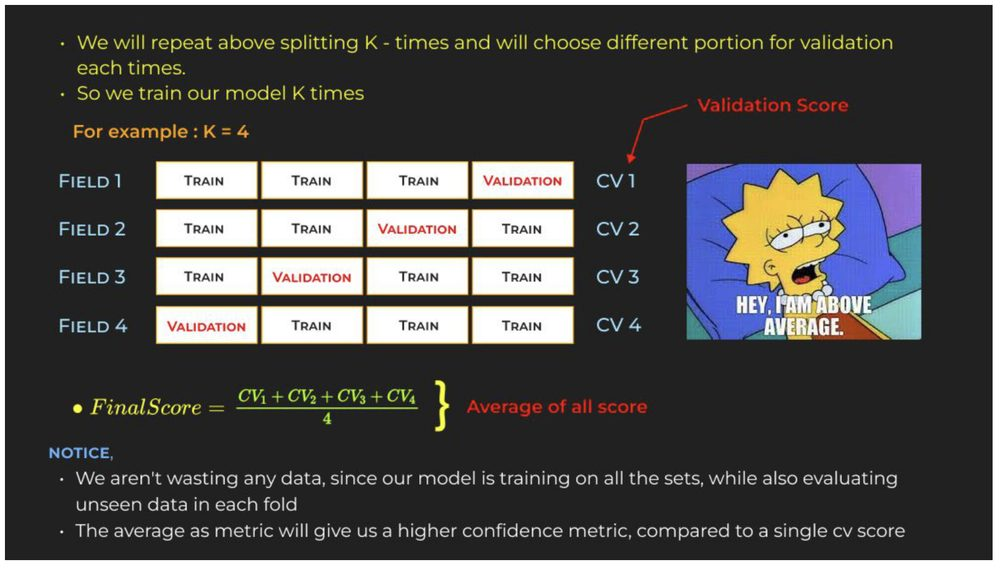

$$
\mathrm{FinalScore} = \frac{1}{K}\sum_{k=1}^{K} \mathrm{CV}_k
$$

**Notes from the script:**

- Useful especially for **smaller** datasets.
- Computationally heavier ($K$ fits per candidate hyperparameter).
- For huge data, a single train/val/test split is often enough.


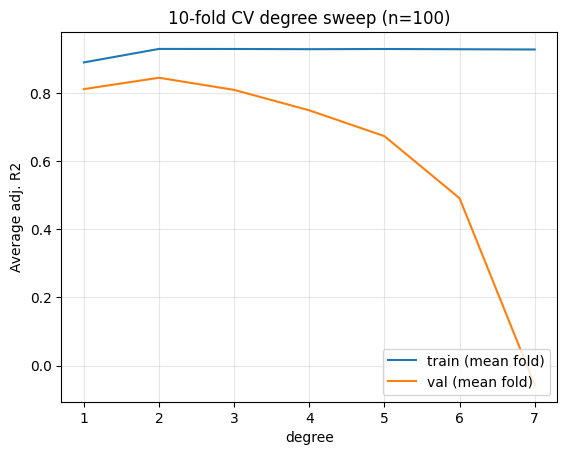

Best degree by mean val adj R2: 2


In [9]:
from sklearn.model_selection import KFold

# Smaller dataset where K-fold helps
np.random.seed(2)
X_small = np.random.rand(100, 1)
y_small = (
    0.7 * (X_small**5)
    - 2.1 * (X_small**4)
    + 2.3 * (X_small**3)
    + 0.2 * (X_small**2)
    + 0.3 * X_small
    + 0.4 * np.random.rand(100, 1)
)

kf = KFold(n_splits=10, shuffle=True, random_state=2)
degrees = 8  # keep adj R2 defined on n_val=10 folds
train_scores, val_scores = [], []

for degree in range(1, degrees):
    fold_train, fold_val = [], []
    for train_index, val_index in kf.split(X_small):
        X_tr, X_va = X_small[train_index], X_small[val_index]
        y_tr, y_va = y_small[train_index], y_small[val_index]
        pipe = make_pipeline(
            PolynomialFeatures(degree), StandardScaler(), LinearRegression()
        )
        pipe.fit(X_tr, y_tr)
        Xt = pipe.named_steps["polynomialfeatures"].transform(X_tr)
        Xv = pipe.named_steps["polynomialfeatures"].transform(X_va)
        fold_train.append(adj_r2(Xt, y_tr, pipe.score(X_tr, y_tr)))
        fold_val.append(adj_r2(Xv, y_va, pipe.score(X_va, y_va)))
    train_scores.append(np.nanmean(fold_train))
    val_scores.append(np.nanmean(fold_val))

plt.figure()
plt.plot(range(1, degrees), train_scores, label="train (mean fold)")
plt.plot(range(1, degrees), val_scores, label="val (mean fold)")
plt.xlabel("degree")
plt.ylabel("Average adj. R2")
plt.legend(loc="lower right")
plt.grid(True, alpha=0.3)
plt.title("10-fold CV degree sweep (n=100)")
plt.show()
print("Best degree by mean val adj R2:", int(np.argmax(val_scores)) + 1)


# 12. Choosing `alpha` with built-in CV (`RidgeCV` / `LassoCV`)

## Talking track

You can hand-roll loops, or use sklearn helpers that run CV over an `alpha` grid.

Still: keep a **final test set** outside the CV used for model selection when you can.


In [10]:
from sklearn.linear_model import RidgeCV, LassoCV
from sklearn.model_selection import cross_val_score

# Use original diabetes features (already roughly scaled in sklearn), still scale in pipeline
Xd, yd = datasets.load_diabetes(return_X_y=True)
X_tr, X_te, y_tr, y_te = train_test_split(Xd, yd, test_size=0.2, random_state=0)

alphas = np.logspace(-3, 3, 30)

ridge_cv = make_pipeline(
    StandardScaler(),
    RidgeCV(alphas=alphas, cv=5),
)
ridge_cv.fit(X_tr, y_tr)
print("RidgeCV chosen alpha:", ridge_cv.named_steps["ridgecv"].alpha_)
print("RidgeCV test R2:", round(ridge_cv.score(X_te, y_te), 4))

lasso_cv = make_pipeline(
    StandardScaler(),
    LassoCV(alphas=alphas, cv=5, max_iter=8000, random_state=0),
)
lasso_cv.fit(X_tr, y_tr)
print("LassoCV chosen alpha:", round(lasso_cv.named_steps["lassocv"].alpha_, 5))
print("LassoCV test R2:", round(lasso_cv.score(X_te, y_te), 4))
print(
    "LassoCV nonzero coefs:",
    int(np.sum(np.abs(lasso_cv.named_steps["lassocv"].coef_) > 1e-8)),
)

# cross_val_score example on the training split only
scores = cross_val_score(
    make_pipeline(StandardScaler(), Ridge(alpha=1.0)),
    X_tr,
    y_tr,
    cv=5,
    scoring="r2",
)
print("5-fold R2 mean±std (Ridge alpha=1):", round(scores.mean(), 4), "±", round(scores.std(), 4))


RidgeCV chosen alpha: 13.738237958832638
RidgeCV test R2: 0.3325
LassoCV chosen alpha: 0.48939
LassoCV test R2: 0.3307
LassoCV nonzero coefs: 9
5-fold R2 mean±std (Ridge alpha=1): 0.5263 ± 0.0363


# 13. Common pitfalls (say these out loud)

1. **Tuning on the test set** repeatedly (test is no longer unseen).
2. **Not scaling** before Ridge / Lasso / ElasticNet (penalty depends on coefficient scale).
3. **Leakage:** fitting `StandardScaler` / `PolynomialFeatures` on train+val+test together. Fit transforms on train (or inside each CV fold via `Pipeline`).
4. **Reporting CV score as final performance** without a held-out test when you still keep searching.
5. **Huge `alpha`:** "regularized" does not mean "good"; you can underfit.
6. **Ignoring correlation structure:** Lasso may arbitrarily pick one of several correlated features; Ridge / ElasticNet can be stabler.


# Quiz 6

**How do we compute the performance metric of a model in k-fold cross-validation?**

- Taking the mean of metric obtained from each fold.
- Selecting the max value of metric obtained from each folds.
- Summing the performance metrics of each fold.
- Calculating the median of k different performance metrics.


# Quiz 7 (pitfalls checkpoint)

**Which practice is safest when scaling features for Ridge?**

- Fit `StandardScaler` on the full dataset, then split.
- Fit `StandardScaler` on train only (or inside a `Pipeline` / each CV fold), then transform val/test.
- Skip scaling because Ridge is invariant to feature scale.
- Scale the target $y$ with the same scaler as $X$ always.


# Wrap-up

1. Regularization adds a weight penalty to the loss so models do not rely on huge coefficients.
2. **Ridge (L2)** shrinks weights; **Lasso (L1)** can zero them (sparse); **ElasticNet** mixes both.
3. $\lambda$ / `alpha` is a **hyperparameter**. Too small → overfit; too large → underfit.
4. Do **not** tune hyperparameters on the final test set. Use validation or K-fold CV, then report test once.
5. K-fold averages validation scores across folds (good for smaller $n$, more compute).
6. Scale features before regularized linear models; keep preprocessing inside pipelines to avoid leakage.
